<a href="https://colab.research.google.com/github/Valdan-D/remorse/blob/main/notebooks/visualizations_Danilo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REMORSE — Visualizzazioni
**Reptilian Evaluation of Mesozoic Origins: Retrospective Study on Extinction**

Visualizzazioni esplorative sui dataset puliti per supportare la narrativa del progetto.

Input: `data/processed/dinos_clean.csv`, `data/processed/plants_clean.csv`

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Stile generale
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Colori progetto
C_DINOS  = '#4A90D9'   # blu
C_PLANTS = '#5BAD72'   # verde

print('Setup completato.')

Setup completato.


## 1. Caricamento dei dataset puliti

In [2]:
BASE = 'https://raw.githubusercontent.com/Valdan-D/remorse/main'

dinos  = pd.read_csv(f'{BASE}/data/processed/dinos_clean.csv', low_memory=False)
plants = pd.read_csv(f'{BASE}/data/processed/plants_clean.csv', low_memory=False)

# Dataset unificato per analisi comparative
df = pd.concat([dinos, plants], ignore_index=True)

print(f'dinos_clean:  {len(dinos):,} righe')
print(f'plants_clean: {len(plants):,} righe')
print(f'Dataset unificato: {len(df):,} righe')

dinos_clean:  21,663 righe
plants_clean: 57,394 righe
Dataset unificato: 79,057 righe


## 2. Distribuzione per periodo geologico

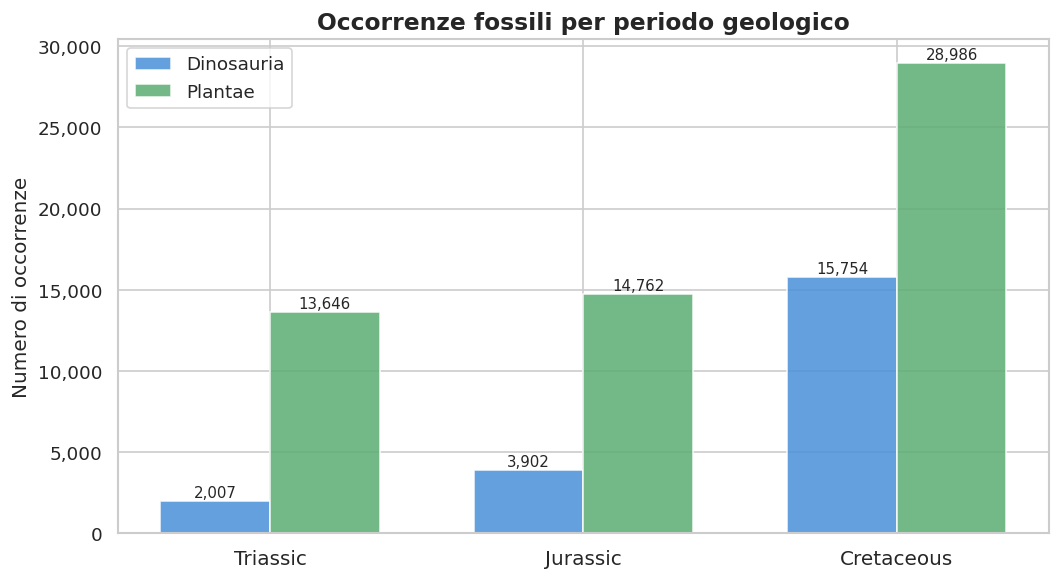

In [3]:
order = ['Triassic', 'Jurassic', 'Cretaceous']

dinos_period  = dinos['period_group'].value_counts().reindex(order, fill_value=0)
plants_period = plants['period_group'].value_counts().reindex(order, fill_value=0)

x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, dinos_period,  width, label='Dinosauria', color=C_DINOS,  alpha=0.85)
bars2 = ax.bar(x + width/2, plants_period, width, label='Plantae',    color=C_PLANTS, alpha=0.85)

ax.set_title('Occorrenze fossili per periodo geologico', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel('Numero di occorrenze')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Timeline — biodiversità nel tempo geologico

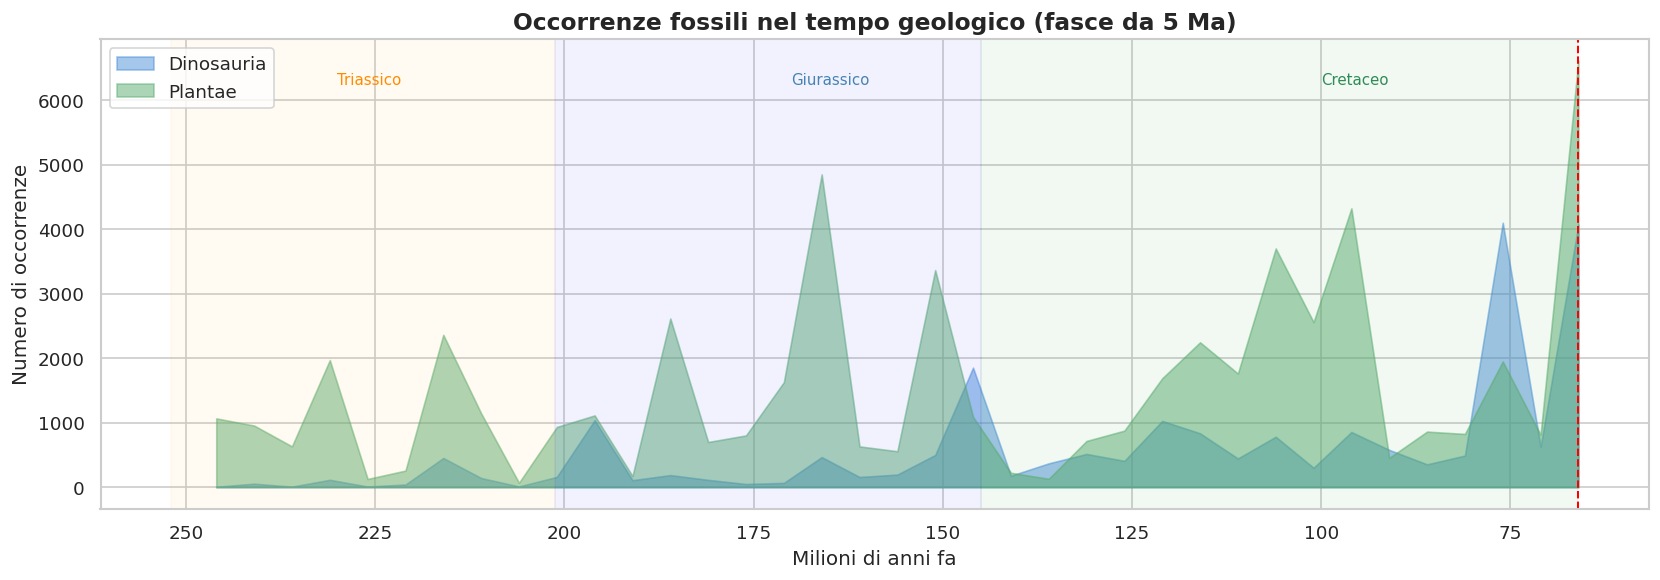

In [4]:
# Raggruppa per fasce di 5 Ma
bin_size = 5
bins = np.arange(66, 253, bin_size)

dinos['ma_bin']  = pd.cut(dinos['mid_ma'],  bins=bins, labels=bins[:-1])
plants['ma_bin'] = pd.cut(plants['mid_ma'], bins=bins, labels=bins[:-1])

dinos_time  = dinos.groupby('ma_bin', observed=True).size()
plants_time = plants.groupby('ma_bin', observed=True).size()

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(dinos_time.index.astype(float),  dinos_time.values,
                alpha=0.5, color=C_DINOS,  label='Dinosauria')
ax.fill_between(plants_time.index.astype(float), plants_time.values,
                alpha=0.5, color=C_PLANTS, label='Plantae')

ax.set_title('Occorrenze fossili nel tempo geologico (fasce da 5 Ma)', fontsize=14, fontweight='bold')
ax.set_xlabel('Milioni di anni fa')
ax.set_ylabel('Numero di occorrenze')
ax.invert_xaxis()
ax.legend()

# Annotazioni ere
ax.axvspan(201.3, 252.0, alpha=0.05, color='orange', label='Triassico')
ax.axvspan(145.0, 201.3, alpha=0.05, color='blue',   label='Giurassico')
ax.axvspan(66.0,  145.0, alpha=0.05, color='green',  label='Cretaceo')
ax.axvline(x=66, color='red', linestyle='--', linewidth=1.2, label='K-Pg (−66 Ma)')

ax.text(230, ax.get_ylim()[1]*0.9, 'Triassico',  fontsize=9, color='darkorange')
ax.text(170, ax.get_ylim()[1]*0.9, 'Giurassico', fontsize=9, color='steelblue')
ax.text(100, ax.get_ylim()[1]*0.9, 'Cretaceo',   fontsize=9, color='seagreen')

plt.tight_layout()
plt.show()

## 4. Top 15 paesi per ritrovamenti

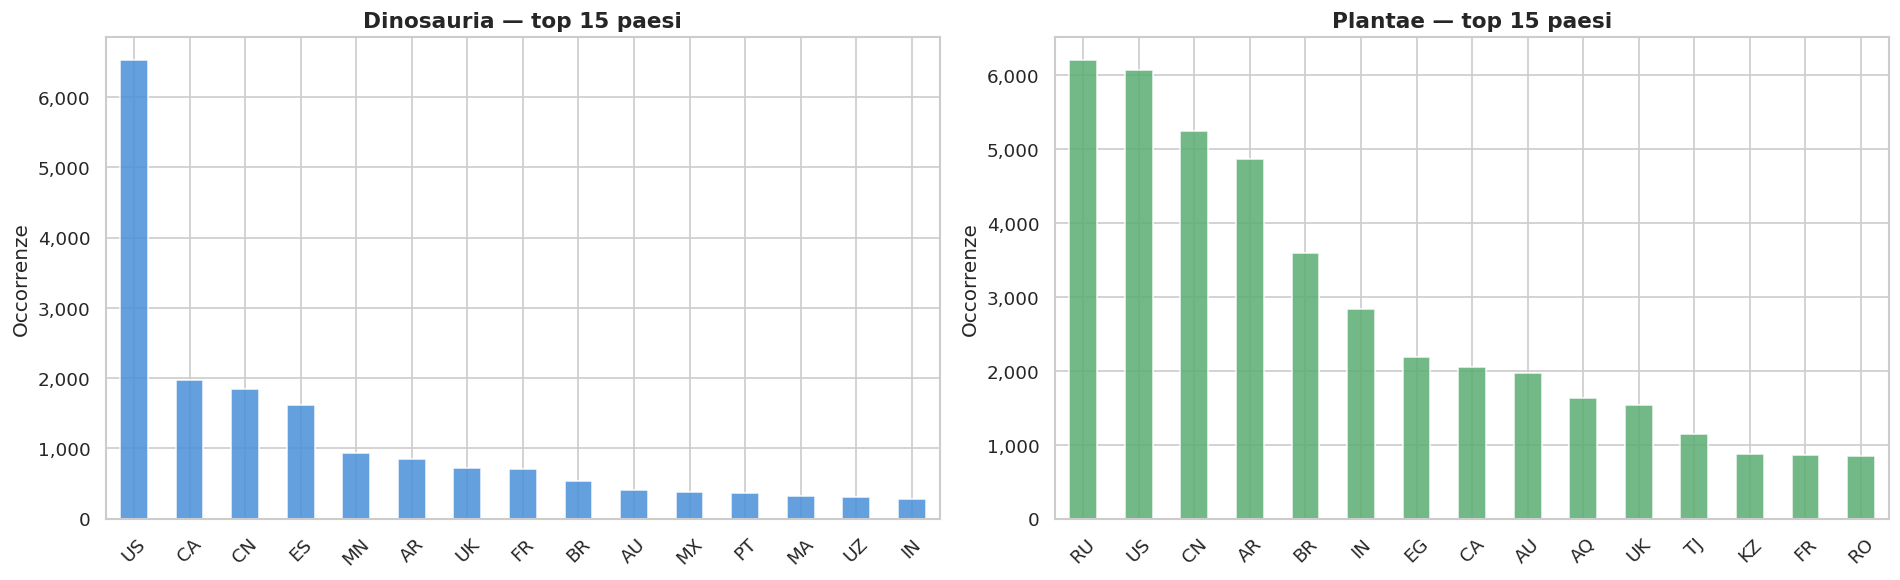

In [5]:
top_dinos  = dinos['cc'].value_counts().head(15)
top_plants = plants['cc'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_dinos.plot(kind='bar', ax=axes[0], color=C_DINOS, alpha=0.85, edgecolor='white')
axes[0].set_title('Dinosauria — top 15 paesi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Occorrenze')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

top_plants.plot(kind='bar', ax=axes[1], color=C_PLANTS, alpha=0.85, edgecolor='white')
axes[1].set_title('Plantae — top 15 paesi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Occorrenze')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.show()

## 5. Co-presenza geografica — mappa

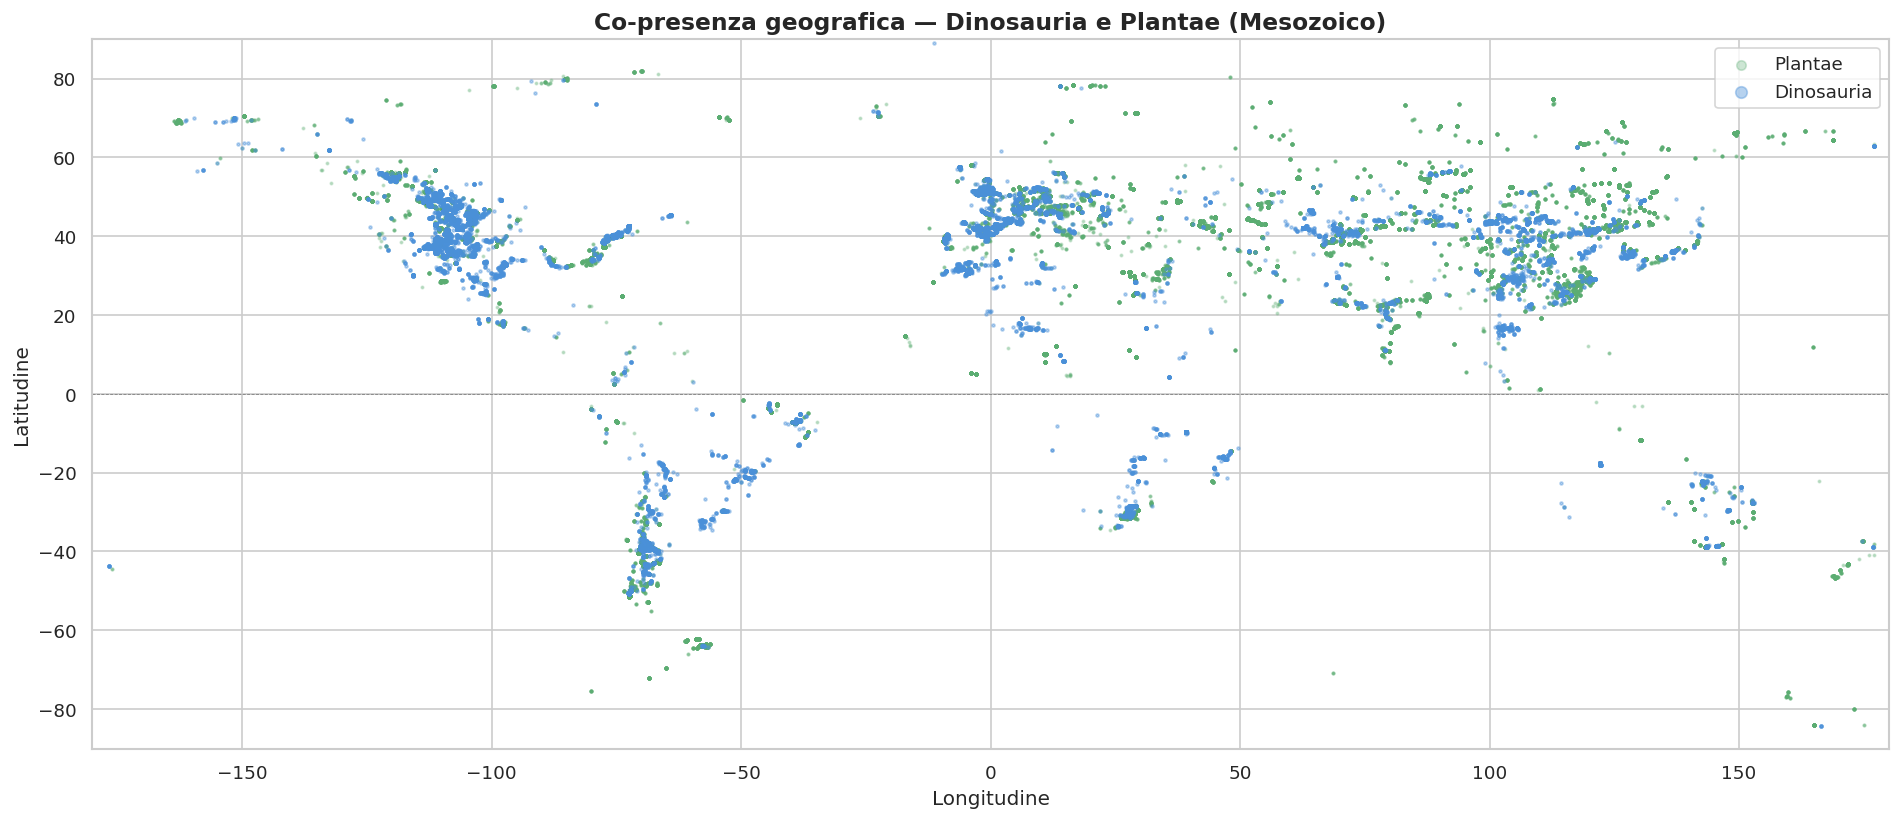

In [6]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.scatter(plants['lng'], plants['lat'],
           s=2, alpha=0.3, color=C_PLANTS, label='Plantae', rasterized=True)
ax.scatter(dinos['lng'], dinos['lat'],
           s=3, alpha=0.4, color=C_DINOS,  label='Dinosauria', rasterized=True)

ax.set_title('Co-presenza geografica — Dinosauria e Plantae (Mesozoico)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitudine')
ax.set_ylabel('Latitudine')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(markerscale=4)

plt.tight_layout()
plt.show()

## 6. Diversità tassonomica — generi distinti per era

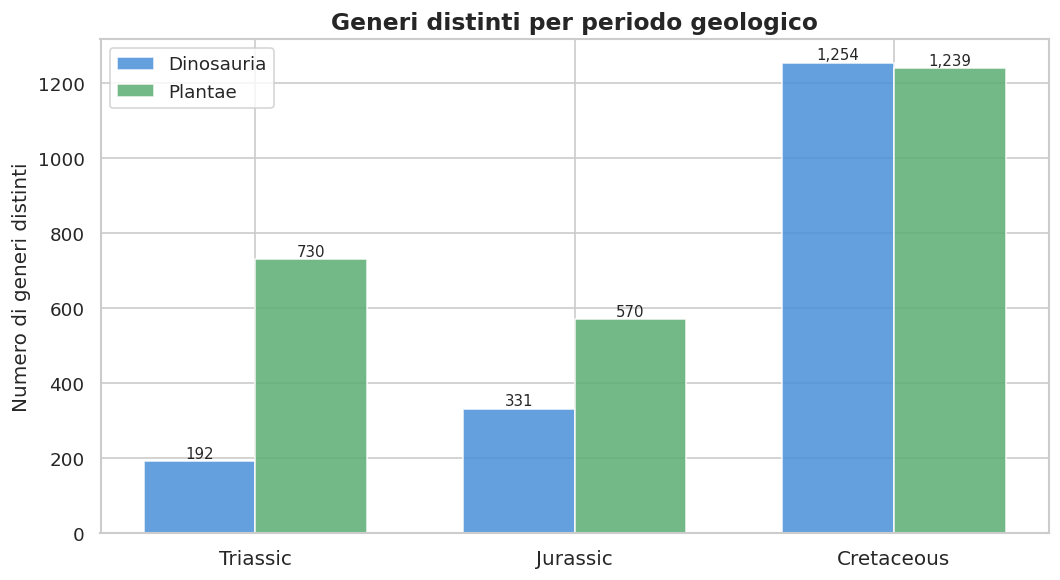

In [7]:
order = ['Triassic', 'Jurassic', 'Cretaceous']

div_dinos  = dinos[dinos['genus'] != 'Unknown'].groupby('period_group')['genus'].nunique().reindex(order, fill_value=0)
div_plants = plants[plants['genus'] != 'Unknown'].groupby('period_group')['genus'].nunique().reindex(order, fill_value=0)

x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, div_dinos,  width, label='Dinosauria', color=C_DINOS,  alpha=0.85)
bars2 = ax.bar(x + width/2, div_plants, width, label='Plantae',    color=C_PLANTS, alpha=0.85)

ax.set_title('Generi distinti per periodo geologico', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel('Numero di generi distinti')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Stacked bar — composizione tassonomica per era

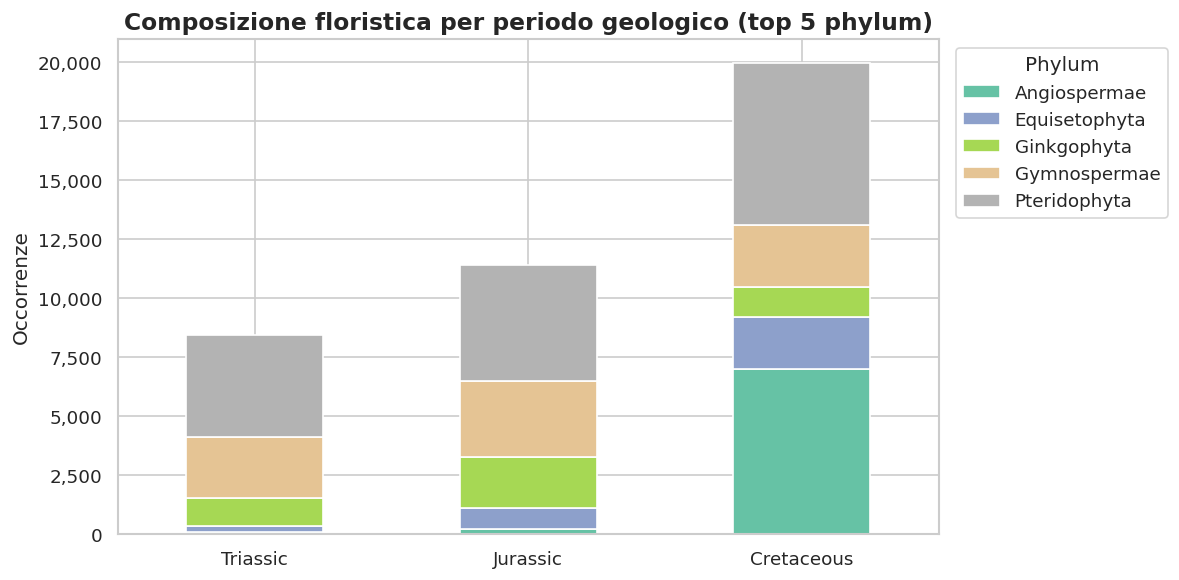

In [8]:
# Top 5 phylum piante per era
top_phyla = plants[plants['phylum'] != 'Unknown']['phylum'].value_counts().head(5).index.tolist()

plants_filtered = plants[plants['phylum'].isin(top_phyla)]
pivot = plants_filtered.groupby(['period_group', 'phylum']).size().unstack(fill_value=0).reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')

ax.set_title('Composizione floristica per periodo geologico (top 5 phylum)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Occorrenze')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Phylum', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.show()